In [ ]:
!git clone https://github.com/unmoIe/vip-commodities-price-prediction.git

In [109]:
import numpy as np
import pandas as pd
import joblib
from abc import ABC, abstractmethod
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
)
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

## Data Loading & Preprocessing

Wheat and corn futures data is loaded from CSV, cleaned of OHLCV formatting issues, and rollover dates are flagged and zeroed out. WTI crude oil is loaded from FRED and forward-filled to match the futures trading calendar.

In [110]:
MACRO_TCODES = {
    'EXUSUKx': 5, 'EXCAUSx': 5, 'PPICMM': 6,
    'FEDFUNDS': 2, 'GS1': 2, 'T10YFFM': 1,
    'S&P 500': 5, 'UMCSENTx': 2, 'RPI': 5,
}

def apply_tcode(s, tcode):
    if tcode == 1: return s
    if tcode == 2: return s.diff()
    if tcode == 3: return s.diff().diff()
    if tcode == 4: return np.log(s.clip(lower=1e-10))
    if tcode == 5: return np.log(s.clip(lower=1e-10)).diff()
    if tcode == 6: return np.log(s.clip(lower=1e-10)).diff().diff()
    return s

def preprocess_commodity_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ['Price', 'Open', 'High', 'Low']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    if 'Vol.' in df.columns:
        def parse_vol(v):
            if pd.isna(v) or str(v).strip() in ('', '-'): return np.nan
            v = str(v).upper().replace(',', '')
            m = 1e3 if 'K' in v else (1e6 if 'M' in v else 1.0)
            try: return float(v.replace('K', '').replace('M', '')) * m
            except: return np.nan
        df['Vol.'] = df['Vol.'].apply(parse_vol)
    if 'Change %' in df.columns:
        df['Change %'] = pd.to_numeric(
            df['Change %'].astype(str).str.replace('%', ''), errors='coerce') / 100
    df = df.ffill().bfill().sort_index()

    ROLL_MONTHS = {3, 5, 7, 9, 12}
    df['is_rollover'] = 0
    for date in ['1999-09-23', '1999-12-21']:
        if date in df.index: df.loc[date, 'is_rollover'] = 1
    for yr in df.index.year.unique():
        if yr == 1999: continue
        for mo in ROLL_MONTHS:
            window = df[(df.index.year == yr) & (df.index.month == mo)
                        & (df.index.day.isin([15, 16, 17]))]
            if not window.empty:
                df.loc[window.index.min(), 'is_rollover'] = 1
    df['Clean_Return'] = df['Change %']
    df.loc[df['is_rollover'] == 1, 'Clean_Return'] = 0.0
    return df

def load_and_align(wheat_path: str, corn_path: str, oil_path: str):
    df_wheat = preprocess_commodity_data(
        pd.read_csv(wheat_path, parse_dates=['Date']).set_index('Date'))
    df_corn = preprocess_commodity_data(
        pd.read_csv(corn_path, parse_dates=['Date']).set_index('Date'))

    df_oil_raw = pd.read_csv(oil_path, parse_dates=['date'])
    df_oil_raw = df_oil_raw.rename(columns={'date': 'Date', 'DCOILWTICO': 'Oil_Price'})
    df_oil_raw = df_oil_raw.set_index('Date').sort_index()
    df_oil_raw['Oil_Price'] = pd.to_numeric(df_oil_raw['Oil_Price'], errors='coerce')
    df_oil_raw = df_oil_raw.ffill().bfill()
    df_oil = df_oil_raw.reindex(
        df_oil_raw.index.union(df_wheat.index)
    ).ffill().reindex(df_wheat.index)

    common = df_wheat.index.intersection(df_corn.index).intersection(df_oil.index)
    print(f"  Wheat : {df_wheat.index.min().date()} → {df_wheat.index.max().date()}  ({len(df_wheat):,} rows)")
    print(f"  Corn  : {df_corn.index.min().date()} → {df_corn.index.max().date()}  ({len(df_corn):,} rows)")
    print(f"  Oil   : {df_oil.index.min().date()} → {df_oil.index.max().date()}  ({len(df_oil):,} rows)")
    print(f"  Common: {common.min().date()} → {common.max().date()}  ({len(common):,} rows)")
    return df_wheat.loc[common], df_corn.loc[common], df_oil.loc[common]

In [111]:
BASE_URL = 'https://raw.githubusercontent.com/unmoIe/vip-commodities-price-prediction/main/'

df_wheat, df_corn, df_oil = load_and_align(
    BASE_URL + 'wheat_prices.csv',
    BASE_URL + 'corn_prices.csv',
    BASE_URL + 'DCOILWTICO.csv',
)

  Wheat : 1999-08-01 → 2025-12-31  (6,876 rows)
  Corn  : 1999-08-02 → 2025-12-31  (6,707 rows)
  Oil   : 1999-08-01 → 2025-12-31  (6,876 rows)
  Common: 1999-08-02 → 2025-12-31  (6,698 rows)


## Exploratory Data Analysis

We examine the raw spread ratio, test for stationarity, and validate that the Z-score signal has a genuine mean-reverting edge before training any model.

In [112]:
def plot_spread_eda(df_wheat, df_corn):
    spread        = df_wheat['Price'] / df_corn['Price']
    spread_zscore = (spread - spread.rolling(60).mean()) / spread.rolling(60).std()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.plot(df_wheat['Price'], label='Wheat', color='#e67e22')
    ax1.plot(df_corn['Price'],  label='Corn',  color='#27ae60')
    ax1.legend()
    ax1.set_title('Wheat vs Corn Prices')
    ax2.plot(spread, color='#2980b9', label='Wheat/Corn Ratio')
    ax2.axhline(spread.mean(), color='red', lw=1, linestyle='--',
                label=f'Mean = {spread.mean():.2f}')
    ax2.legend()
    ax2.set_title('Wheat/Corn Price Ratio')
    plt.tight_layout()
    plt.savefig('spread_eda.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Date range : {df_wheat.index.min().date()} → {df_wheat.index.max().date()}")
    print(f"Total rows : {len(df_wheat):,}")
    print(f"\nSpread ratio stats:\n{spread.describe().round(3)}")
    return spread, spread_zscore


def run_adf_test(spread):
    result = adfuller(spread.dropna(), autolag='AIC')
    print(f"ADF Statistic  : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    print(f"Critical values:")
    for k, v in result[4].items():
        print(f"  {k}: {v:.4f}")
    if result[1] < 0.05:
        print("\nREJECT H0 — spread is stationary. Mean-reversion signal is valid.")
    else:
        print("\nFAIL TO REJECT H0 — spread may be a random walk. Signal is weak.")


def plot_zscore_eda(spread, spread_zscore):
    print("Z-score stats:")
    print(spread_zscore.describe().round(3))
    for threshold in [1.0, 1.5, 2.0]:
        pct = (spread_zscore.abs() > threshold).mean()
        print(f"  |Z| > {threshold}: {pct:.1%} of days")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.plot(spread, color='#2980b9')
    ax1.axhline(spread.mean(), color='red', lw=1, linestyle='--', label='Mean')
    ax1.set_title('Wheat/Corn Price Ratio')
    ax1.legend()
    ax2.plot(spread_zscore, color='#8e44ad', lw=0.8)
    ax2.axhline(0,    color='black', lw=1)
    ax2.axhline( 1.5, color='red',   lw=1, linestyle='--', label='+1.5σ')
    ax2.axhline(-1.5, color='green', lw=1, linestyle='--', label='-1.5σ')
    ax2.set_title('Rolling Z-Score (60-day window)')
    ax2.legend()
    plt.tight_layout()
    plt.savefig('zscore_eda.png', dpi=150, bbox_inches='tight')
    plt.show()


def run_mean_reversion_analysis(spread, spread_zscore):
    fwd_5d = spread.pct_change(5).shift(-5)

    for label, mask in [
        ('Z > +1.5  (wheat expensive)', spread_zscore > 1.5),
        ('Z < -1.5  (wheat cheap)',     spread_zscore < -1.5),
        ('|Z| < 1.5 (neutral)',         spread_zscore.abs() <= 1.5),
    ]:
        fwd = fwd_5d[mask].dropna()
        print(f"{label}")
        print(f"  Mean 5d fwd return : {fwd.mean():.4f}  |  Std: {fwd.std():.4f}  |  n={len(fwd)}")
        print(f"  Hit rate           : {(fwd < 0).mean():.1%}")
        print()

    df_combined = pd.DataFrame({
        'spread' : spread,
        'zscore' : spread_zscore,
        'fwd_5d' : fwd_5d,
    }, index=spread.index).dropna()

    periods = [
        ('2000–2008', '2000-01-01', '2008-12-31'),
        ('2009–2017', '2009-01-01', '2017-12-31'),
        ('2018–2025', '2018-01-01', '2025-12-31'),
    ]

    print("Hit rate (Z > +1.5, spread should fall) by period:")
    for label, start, end in periods:
        sub = df_combined.loc[start:end]
        fwd = sub.loc[sub['zscore'] > 1.5, 'fwd_5d']
        if len(fwd) > 10:
            print(f"  {label}: {(fwd < 0).mean():.1%}  (n={len(fwd)})")

    print("\nHit rate (Z < -1.5, spread should rise) by period:")
    for label, start, end in periods:
        sub = df_combined.loc[start:end]
        fwd = sub.loc[sub['zscore'] < -1.5, 'fwd_5d']
        if len(fwd) > 10:
            print(f"  {label}: {(fwd > 0).mean():.1%}  (n={len(fwd)})")


def plot_rollover_fix(df_wheat):
    mask      = (df_wheat.index >= '2005-01-01') & (df_wheat.index <= '2010-12-31')
    dates     = df_wheat.index[mask]
    dirty     = df_wheat['Change %'][mask]
    clean     = df_wheat['Clean_Return'][mask]
    roll_mask = df_wheat['is_rollover'][mask] == 1
    roll_idx  = df_wheat.index[mask][roll_mask]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.patch.set_facecolor('#0D1B2A')
    for ax in (ax1, ax2):
        ax.set_facecolor('#152535')
        ax.tick_params(colors='#8BA3B0')
        ax.spines[:].set_color('#1E3A4F')
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_color('#8BA3B0')

    ax1.plot(dates, dirty * 100, color='#8BA3B0', lw=0.8, alpha=0.9, label='Daily Return %')
    ax1.scatter(roll_idx, dirty[roll_mask] * 100, color='#E05C5C', s=60, zorder=5, label='Rollover day')
    for rd in roll_idx:
        ax1.axvline(rd, color='#E05C5C', lw=0.8, alpha=0.4, linestyle='--')
    ax1.set_ylabel('Return %', color='#8BA3B0', fontsize=11)
    ax1.set_title('BEFORE — Raw Daily Returns (artificial rollover spikes visible)',
                  color='#FFBC42', fontsize=12, fontweight='bold', pad=8)
    ax1.legend(facecolor='#1E3A4F', edgecolor='#1B998B', labelcolor='white', fontsize=9)
    ax1.axhline(0, color='#1B998B', lw=0.6, alpha=0.5)

    ax2.plot(dates, clean * 100, color='#1B998B', lw=0.8, alpha=0.9, label='Clean Return %')
    for rd in roll_idx:
        ax2.axvline(rd, color='#E05C5C', lw=0.8, alpha=0.4, linestyle='--')
    ax2.scatter(roll_idx, [0] * len(roll_idx), color='#E05C5C', s=60, zorder=5, label='Rollover day (zeroed)')
    ax2.set_ylabel('Return %', color='#8BA3B0', fontsize=11)
    ax2.set_title('AFTER — Clean Returns (rollover days zeroed out)',
                  color='#1B998B', fontsize=12, fontweight='bold', pad=8)
    ax2.legend(facecolor='#1E3A4F', edgecolor='#1B998B', labelcolor='white', fontsize=9)
    ax2.axhline(0, color='#1B998B', lw=0.6, alpha=0.5)
    ax2.set_xlabel('Date', color='#8BA3B0', fontsize=11)

    fig.suptitle('Wheat Futures — Rollover Artefact Detection & Correction  (2005–2010)',
                 color='white', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('rollover_fix.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
    plt.show()
    print("Rollover dates in window:", list(roll_idx.strftime('%Y-%m-%d')))

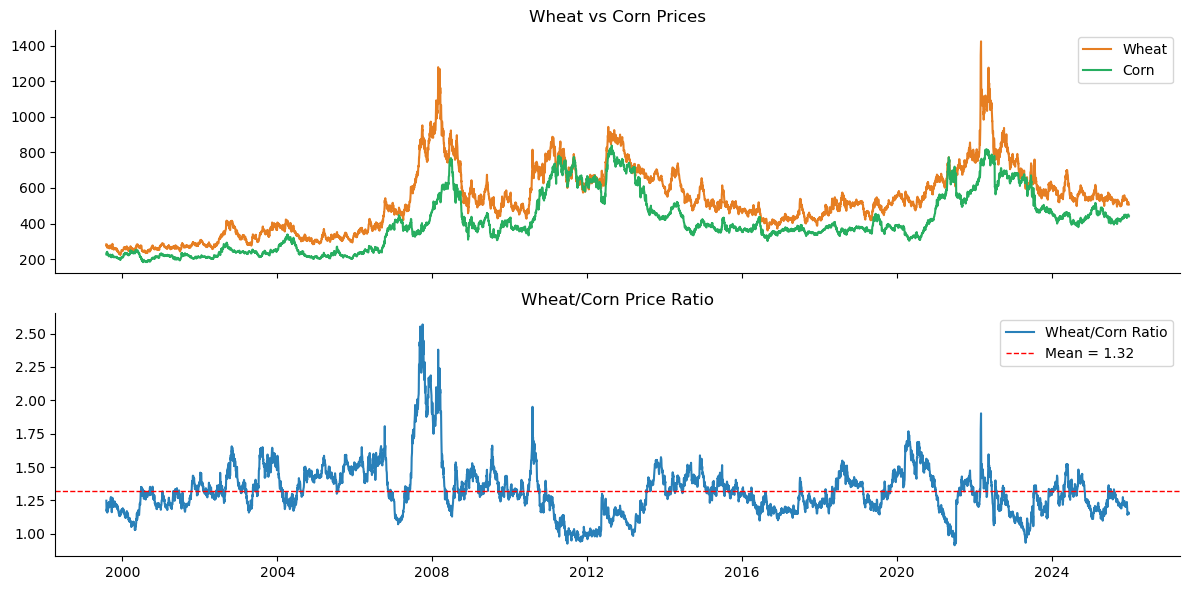

Date range : 1999-08-02 → 2025-12-31
Total rows : 6,698

Spread ratio stats:
count    6698.000
mean        1.321
std         0.195
min         0.915
25%         1.203
50%         1.305
75%         1.412
max         2.568
Name: Price, dtype: float64
ADF Statistic  : -5.2118
p-value        : 0.0000
Critical values:
  1%: -3.4313
  5%: -2.8620
  10%: -2.5670

REJECT H0 — spread is stationary. Mean-reversion signal is valid.
Z-score stats:
count    6639.000
mean       -0.044
std         1.335
min        -3.883
25%        -1.066
50%        -0.161
75%         0.927
max         5.773
Name: Price, dtype: float64
  |Z| > 1.0: 50.3% of days
  |Z| > 1.5: 28.6% of days
  |Z| > 2.0: 12.4% of days


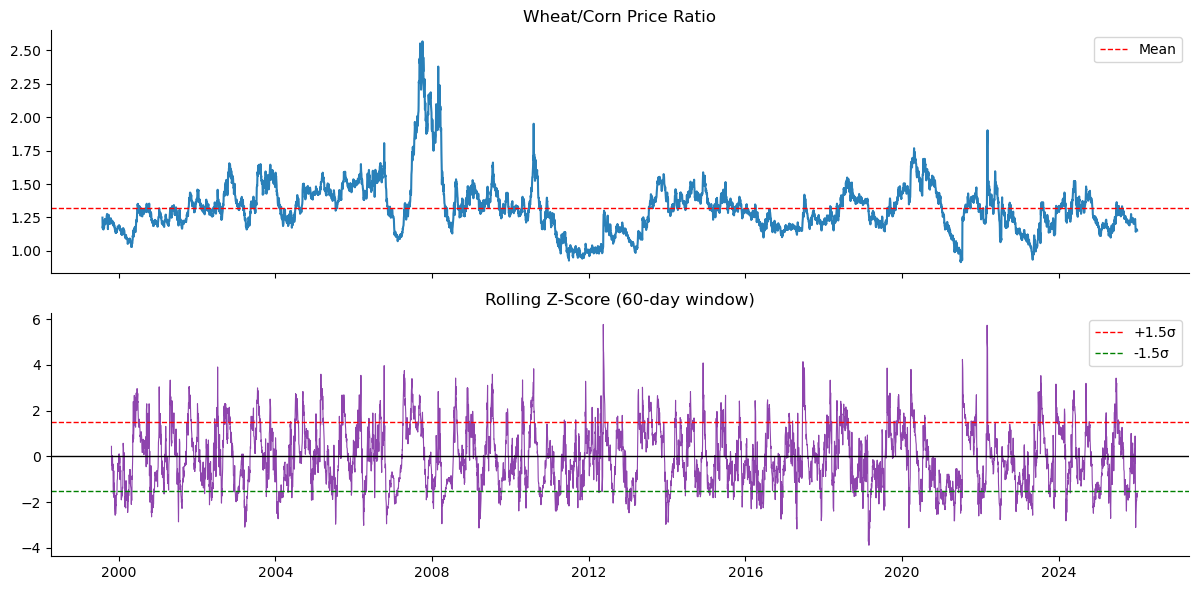

Z > +1.5  (wheat expensive)
  Mean 5d fwd return : -0.0049  |  Std: 0.0450  |  n=927
  Hit rate           : 59.0%

Z < -1.5  (wheat cheap)
  Mean 5d fwd return : 0.0029  |  Std: 0.0378  |  n=983
  Hit rate           : 49.3%

|Z| < 1.5 (neutral)
  Mean 5d fwd return : 0.0014  |  Std: 0.0391  |  n=4724
  Hit rate           : 52.2%

Hit rate (Z > +1.5, spread should fall) by period:
  2000–2008: 55.6%  (n=390)
  2009–2017: 66.2%  (n=281)
  2018–2025: 56.2%  (n=256)

Hit rate (Z < -1.5, spread should rise) by period:
  2000–2008: 44.8%  (n=310)
  2009–2017: 56.7%  (n=293)
  2018–2025: 50.7%  (n=361)


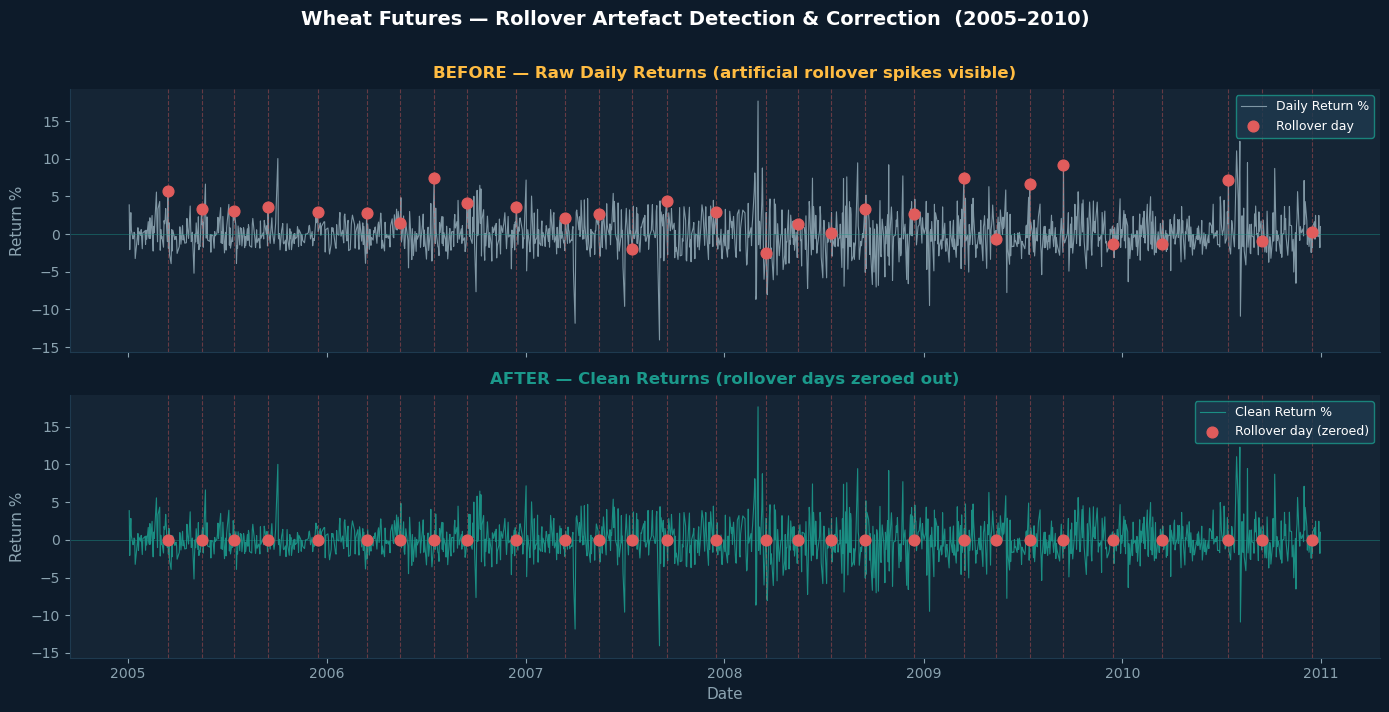

Rollover dates in window: ['2005-03-15', '2005-05-16', '2005-07-15', '2005-09-15', '2005-12-15', '2006-03-15', '2006-05-15', '2006-07-17', '2006-09-15', '2006-12-15', '2007-03-15', '2007-05-15', '2007-07-16', '2007-09-17', '2007-12-17', '2008-03-17', '2008-05-15', '2008-07-15', '2008-09-15', '2008-12-15', '2009-03-16', '2009-05-15', '2009-07-15', '2009-09-15', '2009-12-15', '2010-03-15', '2010-07-15', '2010-09-15', '2010-12-15']


In [113]:
spread, spread_zscore = plot_spread_eda(df_wheat, df_corn)
run_adf_test(spread)
plot_zscore_eda(spread, spread_zscore)
run_mean_reversion_analysis(spread, spread_zscore)
plot_rollover_fix(df_wheat)

## Feature Engineering

Two feature sets are built from the same underlying data:

- **Model A (Base):** Spread Z-scores, momentum, volatility, seasonality, and individual leg features.
- **Model B (Oil-Enhanced):** All of Model A's features plus WTI crude oil momentum and Z-score features to capture the Energy-Corn input cost channel.

Both sets are filtered to trading days where |Z-score₆₀d| > 2.0 only.

In [114]:
HORIZON       = 5
SIGNAL_THRESH = 2.0

def build_base_features(df_wheat, df_corn):
    spread     = df_wheat['Price'] / df_corn['Price']
    log_spread = np.log(spread)
    X = pd.DataFrame(index=spread.index)

    for w in [10, 20, 40, 60, 90, 120]:
        X[f'ZScore_{w}d'] = (spread - spread.rolling(w).mean()) / spread.rolling(w).std()

    X['Spread_Mom_3d']  = log_spread.diff(3)
    X['Spread_Mom_5d']  = log_spread.diff(5)
    X['Spread_Mom_10d'] = log_spread.diff(10)
    X['Spread_Mom_15d'] = log_spread.diff(15)
    X['Spread_Mom_20d'] = log_spread.diff(20)
    X['Spread_Mom_30d'] = log_spread.diff(30)

    X['Spread_Vol_5d']  = log_spread.diff().rolling(5).std()
    X['Spread_Vol_10d'] = log_spread.diff().rolling(10).std()
    X['Spread_Vol_20d'] = log_spread.diff().rolling(20).std()
    X['Spread_Vol_30d'] = log_spread.diff().rolling(30).std()

    X['Month_Sin'] = np.sin(2 * np.pi * spread.index.month / 12)
    X['Month_Cos'] = np.cos(2 * np.pi * spread.index.month / 12)

    X['Wheat_Mom_5d'] = np.log1p(df_wheat['Clean_Return']).rolling(5).sum()
    X['Corn_Mom_5d']  = np.log1p(df_corn['Clean_Return']).rolling(5).sum()

    X['Wheat_Mom_10d'] = np.log1p(df_wheat['Clean_Return']).rolling(10).sum()
    X['Corn_Mom_10d']  = np.log1p(df_corn['Clean_Return']).rolling(10).sum()
    X['Wheat_Mom_20d'] = np.log1p(df_wheat['Clean_Return']).rolling(20).sum()
    X['Corn_Mom_20d']  = np.log1p(df_corn['Clean_Return']).rolling(20).sum()

    X['Vol_Ratio']     = (
        df_wheat['Clean_Return'].rolling(10).std() /
        (df_corn['Clean_Return'].rolling(10).std() + 1e-10)
    )
    X['Vol_Ratio_5d']  = (
        df_wheat['Clean_Return'].rolling(5).std() /
        (df_corn['Clean_Return'].rolling(5).std() + 1e-10)
    )
    X['Vol_Ratio_20d'] = (
        df_wheat['Clean_Return'].rolling(20).std() /
        (df_corn['Clean_Return'].rolling(20).std() + 1e-10)
    )

    return X, spread


def add_oil_features(X, df_oil):
    X = X.copy()
    log_oil       = np.log(df_oil['Oil_Price'])
    oil_roll_mean = df_oil['Oil_Price'].rolling(60).mean()
    oil_roll_std  = df_oil['Oil_Price'].rolling(60).std()

    X['Oil_Ret_5d']     = log_oil.diff(5)
    X['Oil_Ret_20d']    = log_oil.diff(20)
    X['Oil_ZScore_60d'] = (df_oil['Oil_Price'] - oil_roll_mean) / (oil_roll_std + 1e-10)
    return X


def build_target_and_filter(X, spread):
    fwd_ret = np.log(spread).diff(HORIZON).shift(-HORIZON)
    Y = pd.Series(np.sign(fwd_ret), index=spread.index, name='Target')

    combined = pd.concat([X, Y], axis=1).dropna()
    combined = combined[combined['Target'] != 0]
    combined = combined[combined['ZScore_60d'].abs() > SIGNAL_THRESH]

    return combined.drop(columns=['Target']), combined[['Target']]

In [115]:
X_base, spread  = build_base_features(df_wheat, df_corn)
X_oil           = add_oil_features(X_base, df_oil)

X_A, Y_A = build_target_and_filter(X_base, spread)
X_B, Y_B = build_target_and_filter(X_oil,  spread)

print(f"Model A (Base)         : {X_A.shape[1]} features,  {len(X_A):,} rows")
print(f"Model B (Oil-Enhanced) : {X_B.shape[1]} features,  {len(X_B):,} rows")

corr_A = np.corrcoef(X_A['ZScore_60d'], Y_A['Target'].values.ravel())[0, 1]
corr_B = np.corrcoef(X_B['ZScore_60d'], Y_B['Target'].values.ravel())[0, 1]
print(f"\nZScore_60d vs Target correlation — A: {corr_A:.3f}  |  B: {corr_B:.3f}")
print("(expect negative)")

Model A (Base)         : 27 features,  825 rows
Model B (Oil-Enhanced) : 30 features,  825 rows

ZScore_60d vs Target correlation — A: -0.122  |  B: -0.122
(expect negative)


## Model Definition & Walk-Forward Validation

Both models use Elastic Net Logistic Regression with identical hyperparameters. Walk-forward expanding-window validation is used — the scaler is fit on the training fold only to prevent leakage.

In [116]:
class BaseForecastModel(ABC):
    def __init__(self, task_type: str, **hyperparameters):
        self.task_type       = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def predict_proba(self, X): pass

    @abstractmethod
    def evaluate(self, X_test, y_test): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass


class ElasticNetLogisticModel(BaseForecastModel):
    def __init__(self, input_dim=None, **hparams):
        super().__init__(task_type='classification', **hparams)
        self.C         = hparams.get('C',        0.1)
        self.l1_ratio  = hparams.get('l1_ratio', 0.5)
        self.max_iter  = hparams.get('max_iter', 1000)
        self.threshold = hparams.get('threshold', 0.50)
        self.model     = LogisticRegression(
            penalty='elasticnet', solver='saga',
            C=self.C, l1_ratio=self.l1_ratio,
            max_iter=self.max_iter,
            class_weight='balanced',
            random_state=42,
        )

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train.ravel())
        print(f"  Fitted — non-zero coefficients: {np.sum(self.model.coef_ != 0)} / {X_train.shape[1]}")

    def predict_proba(self, X) -> np.ndarray:
        return self.model.predict_proba(X)[:, 1]

    def predict(self, X, threshold=None) -> np.ndarray:
        thresh = threshold if threshold is not None else self.threshold
        return np.where(self.predict_proba(X) >= thresh, 1, -1)

    def evaluate(self, X_test, y_test) -> float:
        acc = float(np.mean(self.predict(X_test) == y_test.ravel()))
        print(f"  Accuracy: {acc:.4f}")
        return acc

    def feature_importance(self, feature_names) -> pd.Series:
        coefs = pd.Series(self.model.coef_.ravel(), index=feature_names)
        return coefs.reindex(coefs.abs().sort_values(ascending=False).index)

    def save(self, filepath: str):
        joblib.dump(self.model, filepath)

    def load(self, filepath: str):
        self.model = joblib.load(filepath)

In [121]:
def walk_forward_validation(X, y, model_cls, hparams, n_splits=5):
    n, fold_size                  = len(X), len(X) // (n_splits + 1)
    all_true, all_pred, all_proba = [], [], []

    for i in range(n_splits):
        train_end = fold_size * (i + 1)
        test_end  = min(train_end + fold_size, n)

        X_tr, y_tr = X.iloc[:train_end].values, y.iloc[:train_end].values.ravel()
        X_te, y_te = X.iloc[train_end:test_end].values, y.iloc[train_end:test_end].values.ravel()

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        model = model_cls(input_dim=X_tr_s.shape[1], **hparams)
        model.fit(X_tr_s, y_tr)

        all_true.append(y_te)
        all_pred.append(model.predict(X_te_s))
        all_proba.append(model.predict_proba(X_te_s))
        print(f"  Fold {i+1}/{n_splits}  train[0:{train_end}]  test[{train_end}:{test_end}]  n={len(y_te)}")

    return (np.concatenate(all_true),
            np.concatenate(all_pred),
            np.concatenate(all_proba))


def calculate_trader_metrics(y_true, y_pred, label=''):
    precision = np.mean(y_pred == y_true)
    print('\n' + '=' * 55)
    print(f'  SPREAD TRADER METRICS  {label}')
    print('=' * 55)
    print(f"  Total Signals : {len(y_pred)}")
    print(f"  Hit Rate      : {precision:.2%}  (edge if > 50%)")
    print(f"  Whipsaw Rate  : {1 - precision:.2%}")
    print()
    print(classification_report(y_true, y_pred, labels=[-1, 1],
                                target_names=['Spread Down', 'Spread Up'],
                                zero_division=0))


def run_threshold_analysis(X_df, y_true_all, y_pred_all):
    fold_size      = len(X_df) // 6
    zscore_test    = X_df['ZScore_60d'].iloc[fold_size:fold_size + len(y_true_all)].values
    print("Hit rate by Z-score threshold:")
    for threshold in [0.0, 0.5, 1.0, 1.5, 2.0]:
        mask = np.abs(zscore_test) > threshold
        if mask.sum() > 50:
            hit = np.mean(y_pred_all[mask] == y_true_all[mask])
            print(f"  |Z| > {threshold:.1f}  →  hit rate={hit:.2%}  signals={mask.sum()}")

In [122]:
HPARAMS_A = dict(C=10, l1_ratio=0.5, max_iter=1000, threshold=0.50)
HPARAMS_B = dict(C=0.1,  l1_ratio=0.5, max_iter=1000, threshold=0.50)

print('=== Model A: Base (no oil) ===')
y_true_A, y_pred_A, y_proba_A = walk_forward_validation(
    X_A, Y_A, ElasticNetLogisticModel, HPARAMS_A)

print('\n=== Model B: Oil-Enhanced ===')
y_true_B, y_pred_B, y_proba_B = walk_forward_validation(
    X_B, Y_B, ElasticNetLogisticModel, HPARAMS_B)

=== Model A: Base (no oil) ===
  Fitted — non-zero coefficients: 27 / 27
  Fold 1/5  train[0:137]  test[137:274]  n=137
  Fitted — non-zero coefficients: 27 / 27
  Fold 2/5  train[0:274]  test[274:411]  n=137
  Fitted — non-zero coefficients: 27 / 27
  Fold 3/5  train[0:411]  test[411:548]  n=137
  Fitted — non-zero coefficients: 27 / 27
  Fold 4/5  train[0:548]  test[548:685]  n=137
  Fitted — non-zero coefficients: 27 / 27
  Fold 5/5  train[0:685]  test[685:822]  n=137

=== Model B: Oil-Enhanced ===
  Fitted — non-zero coefficients: 9 / 30
  Fold 1/5  train[0:137]  test[137:274]  n=137
  Fitted — non-zero coefficients: 13 / 30
  Fold 2/5  train[0:274]  test[274:411]  n=137
  Fitted — non-zero coefficients: 19 / 30
  Fold 3/5  train[0:411]  test[411:548]  n=137
  Fitted — non-zero coefficients: 16 / 30
  Fold 4/5  train[0:548]  test[548:685]  n=137
  Fitted — non-zero coefficients: 18 / 30
  Fold 5/5  train[0:685]  test[685:822]  n=137


## Model Evaluation & Comparison

Both models are evaluated on their respective out-of-sample walk-forward test periods. Since both use the same Z-score filter and target, the comparison isolates the marginal value of the oil features.

In [123]:
calculate_trader_metrics(y_true_A, y_pred_A, label='Model A — Base')
run_threshold_analysis(X_A, np.array(y_true_A), np.array(y_pred_A))

calculate_trader_metrics(y_true_B, y_pred_B, label='Model B — Oil-Enhanced')
run_threshold_analysis(X_B, np.array(y_true_B), np.array(y_pred_B))


  SPREAD TRADER METRICS  Model A — Base
  Total Signals : 685
  Hit Rate      : 55.18%  (edge if > 50%)
  Whipsaw Rate  : 44.82%

              precision    recall  f1-score   support

 Spread Down       0.57      0.55      0.56       355
   Spread Up       0.53      0.56      0.55       330

    accuracy                           0.55       685
   macro avg       0.55      0.55      0.55       685
weighted avg       0.55      0.55      0.55       685

Hit rate by Z-score threshold:
  |Z| > 0.0  →  hit rate=55.18%  signals=685
  |Z| > 0.5  →  hit rate=55.18%  signals=685
  |Z| > 1.0  →  hit rate=55.18%  signals=685
  |Z| > 1.5  →  hit rate=55.18%  signals=685
  |Z| > 2.0  →  hit rate=55.18%  signals=685

  SPREAD TRADER METRICS  Model B — Oil-Enhanced
  Total Signals : 685
  Hit Rate      : 57.81%  (edge if > 50%)
  Whipsaw Rate  : 42.19%

              precision    recall  f1-score   support

 Spread Down       0.60      0.57      0.59       355
   Spread Up       0.56      0.58     

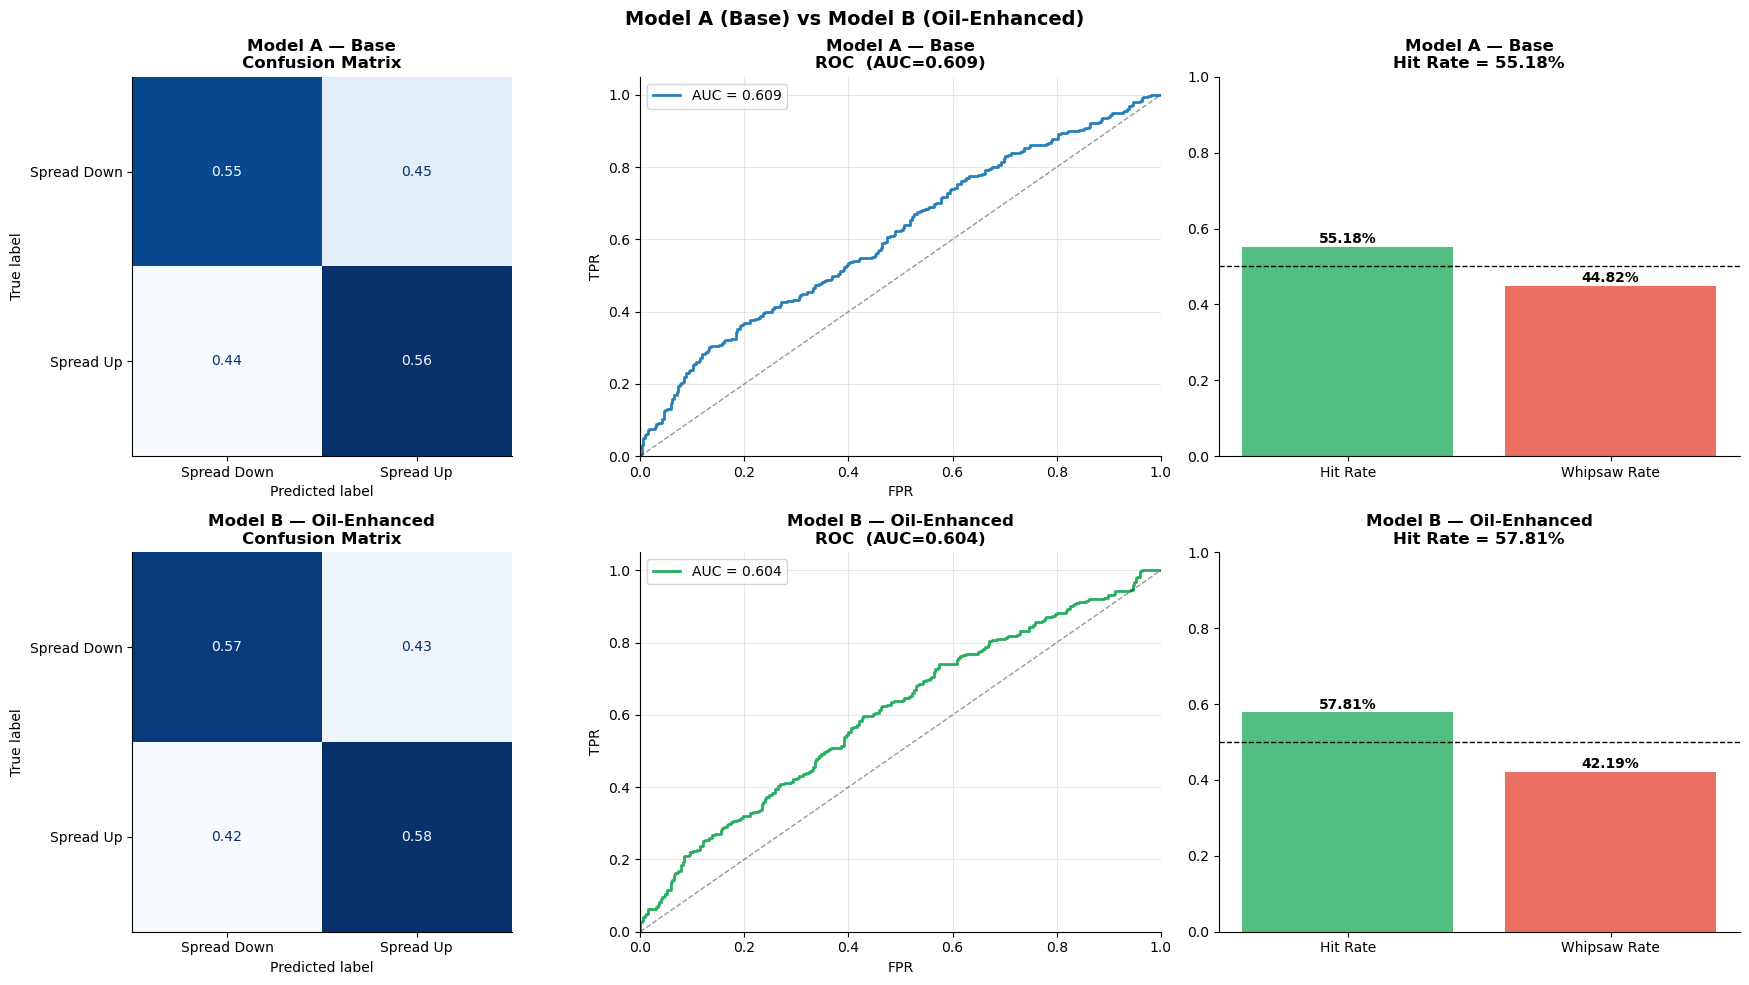

In [124]:
def plot_comparison(y_true_A, y_pred_A, y_proba_A,
                    y_true_B, y_pred_B, y_proba_B):

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Model A (Base) vs Model B (Oil-Enhanced)',
                 fontsize=14, fontweight='bold')

    for row, (y_true, y_pred, y_proba, label) in enumerate([
        (y_true_A, y_pred_A, y_proba_A, 'Model A — Base'),
        (y_true_B, y_pred_B, y_proba_B, 'Model B — Oil-Enhanced'),
    ]):
        cm = confusion_matrix(y_true, y_pred, labels=[-1, 1], normalize='true')
        ConfusionMatrixDisplay(cm, display_labels=['Spread Down', 'Spread Up']).plot(
            ax=axes[row, 0], cmap='Blues', colorbar=False, values_format='.2f')
        axes[row, 0].set_title(f'{label}\nConfusion Matrix', fontweight='bold')

        y_bin       = ((y_true + 1) // 2).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_proba)
        auc         = roc_auc_score(y_bin, y_proba)
        axes[row, 1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}',
                          color='#2980b9' if row == 0 else '#27ae60')
        axes[row, 1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
        axes[row, 1].set(xlabel='FPR', ylabel='TPR', xlim=[0,1], ylim=[0,1.05])
        axes[row, 1].set_title(f'{label}\nROC  (AUC={auc:.3f})', fontweight='bold')
        axes[row, 1].legend()
        axes[row, 1].grid(alpha=0.3)

        hit = np.mean(y_pred == y_true)
        axes[row, 2].bar(['Hit Rate', 'Whipsaw Rate'], [hit, 1 - hit],
                         color=['#27ae60', '#e74c3c'], alpha=0.8)
        axes[row, 2].set_ylim(0, 1)
        axes[row, 2].axhline(0.5, color='black', lw=1, linestyle='--')
        axes[row, 2].set_title(f'{label}\nHit Rate = {hit:.2%}', fontweight='bold')
        for i, v in enumerate([hit, 1 - hit]):
            axes[row, 2].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_comparison(y_true_A, y_pred_A, y_proba_A,
                y_true_B, y_pred_B, y_proba_B)

  Fitted — non-zero coefficients: 27 / 27
  Fitted — non-zero coefficients: 17 / 30


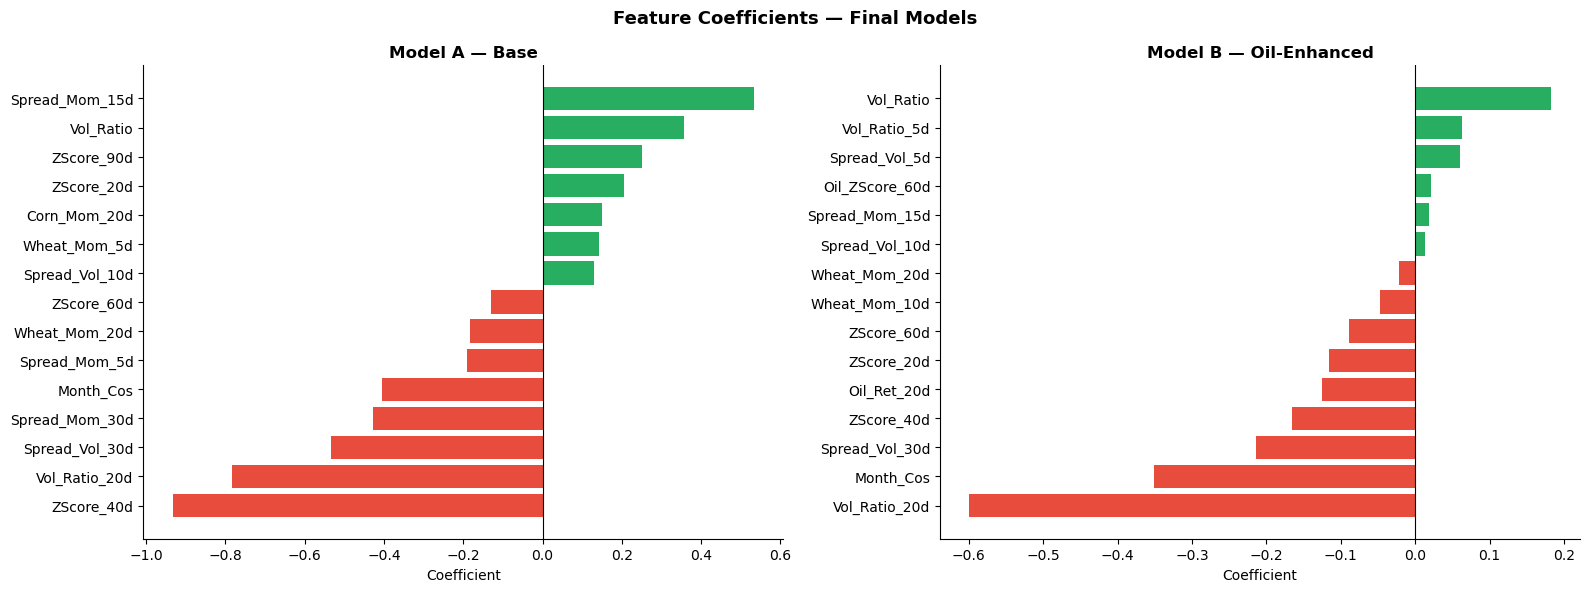

In [108]:
def fit_final_model(X_df, Y_df, hparams):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df.values)
    model = ElasticNetLogisticModel(input_dim=X_df.shape[1], **hparams)
    model.fit(X_scaled, Y_df.values.ravel())
    return model

final_A = fit_final_model(X_A, Y_A, HPARAMS_A)
final_B = fit_final_model(X_B, Y_B, HPARAMS_B)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Coefficients — Final Models', fontsize=13, fontweight='bold')

for ax, model, X_df, label in [
    (ax1, final_A, X_A, 'Model A — Base'),
    (ax2, final_B, X_B, 'Model B — Oil-Enhanced'),
]:
    coef_s  = pd.Series(model.model.coef_.ravel(), index=X_df.columns)
    top15   = coef_s.abs().nlargest(15).index
    top15_s = coef_s.loc[top15].sort_values()
    colors  = ['#e74c3c' if v < 0 else '#27ae60' for v in top15_s]
    ax.barh(top15_s.index, top15_s.values, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('coefficients_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Wheat / Corn Spread Trading Strategy

## Assumptions

| # | Assumption | Detail |
|---|---|---|
| 1 | **Instrument** | Continuous front-month futures: CBOT Wheat (ZW) vs CBOT Corn (ZC) |
| 2 | **Spread definition** | Spread = Wheat Price / Corn Price (ratio, not difference) |
| 3 | **Capital** | $100,000 notional, fully allocated to spread trades |
| 4 | **Position unit** | 1 spread unit = long 1 ZW contract + short 1 ZC contract (or vice versa) |
| 5 | **Execution** | Trade fills at next-day open; no partial fills assumed |
| 6 | **Transaction costs** | $10 round-trip per contract per leg ($20 per spread trade) |
| 7 | **Slippage** | 0.05% of notional per trade |
| 8 | **Rollover days** | Zeroed out in returns (`Clean_Return`); no position held through rollover |
| 9 | **No leverage** | Max position = capital / current spread notional |
| 10 | **Stationarity** | All features are returns or Z-scores — no raw price levels in the model |

## Signal

The model outputs **P(spread rises)** — the predicted probability that the
wheat/corn ratio will be higher 5 trading days from now.

A trade is only triggered when **two conditions are jointly satisfied**:

1. **Model conviction**: |P - 0.5| > conviction threshold (default 0.10)
   — i.e. the model must predict with at least 60% confidence in either direction
2. **Z-score filter**: |Z-score₆₀d of spread| > 2.0
   — i.e. the spread must be statistically stretched; we never fade a neutral spread

## Position Sizing

Conviction-scaled sizing — larger positions when the model is more certain:

| Model Probability | Conviction | Position Size |
|---|---|---|
| > 0.70 or < 0.30 | High | 100% of max unit |
| 0.60–0.70 or 0.30–0.40 | Medium | 60% of max unit |
| 0.55–0.60 or 0.40–0.45 | Low | 30% of max unit |
| 0.45–0.55 | None | No trade |

## Trade Direction

| Condition | Action |
|---|---|
| P > threshold AND Z < -2 | **Long spread** (buy wheat, sell corn) — spread expected to rise back to mean |
| P < (1-threshold) AND Z > +2 | **Short spread** (sell wheat, buy corn) — spread expected to fall back to mean |

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

CAPITAL       = 100_000
COST_PER_LEG  = 10
SLIPPAGE_PCT  = 0.0005
HORIZON       = 5
SIGNAL_THRESH = 2.0

CONVICTION_HIGH = 0.70
CONVICTION_MED  = 0.60
CONVICTION_LOW  = 0.55

SIZE_HIGH = 1.00
SIZE_MED  = 0.60
SIZE_LOW  = 0.30

LIGHT = {
    'bg'      : '#FFFFFF',
    'panel'   : '#F7F9FC',
    'grid'    : '#E2E8F0',
    'text'    : '#1A202C',
    'subtext' : '#4A5568',
    'green'   : '#276749',
    'red'     : '#9B2335',
    'blue'    : '#2B6CB0',
    'orange'  : '#C05621',
    'border'  : '#CBD5E0',
}

pct_fmt    = FuncFormatter(lambda x, _: f'{x:.0%}')

## Strategy Functions

Signal is generated from the model's predicted probability and the 60-day Z-score of the spread.
Position sizing scales with model conviction. Each trade is held for 5 days with transaction costs and slippage applied.

In [128]:
def build_strategy(X_df, Y_df, df_wheat, df_corn, y_proba_all, n_splits=5):
    n         = len(X_df)
    fold_size = n // (n_splits + 1)

    test_indices = []
    for i in range(n_splits):
        train_end = fold_size * (i + 1)
        test_end  = min(train_end + fold_size, n)
        test_indices.extend(range(train_end, test_end))

    signal_idx = X_df.index[test_indices]
    proba      = pd.Series(y_proba_all, index=signal_idx, name='Proba')
    zscore     = X_df['ZScore_60d'].reindex(signal_idx)

    def get_size(p):
        dev = abs(p - 0.5)
        if dev >= (CONVICTION_HIGH - 0.5): return SIZE_HIGH
        if dev >= (CONVICTION_MED  - 0.5): return SIZE_MED
        if dev >= (CONVICTION_LOW  - 0.5): return SIZE_LOW
        return 0.0

    def get_direction(p, z):
        if p > CONVICTION_LOW and z < -SIGNAL_THRESH:       return  1
        if p < (1 - CONVICTION_LOW) and z > SIGNAL_THRESH:  return -1
        return 0

    trades = []
    for date in signal_idx:
        p         = proba[date]
        z         = zscore[date]
        direction = get_direction(p, z)
        if direction == 0:
            continue
        size_pct = get_size(p)

        future_dates = df_wheat.index[df_wheat.index > date]
        if len(future_dates) < HORIZON:
            continue
        exit_date = future_dates[HORIZON - 1]

        w_ret = df_wheat.loc[
            (df_wheat.index > date) & (df_wheat.index <= exit_date), 'Clean_Return'
        ].sum()
        c_ret = df_corn.loc[
            (df_corn.index > date) & (df_corn.index <= exit_date), 'Clean_Return'
        ].sum()

        spread_ret = w_ret - c_ret
        trade_ret  = direction * spread_ret
        notional   = CAPITAL * size_pct
        gross_pnl  = notional * trade_ret
        costs      = (COST_PER_LEG * 2) + (notional * SLIPPAGE_PCT * 2)
        net_pnl    = gross_pnl - costs

        trades.append({
            'entry_date' : date,
            'exit_date'  : exit_date,
            'direction'  : direction,
            'proba'      : p,
            'zscore'     : z,
            'size_pct'   : size_pct,
            'notional'   : notional,
            'spread_ret' : spread_ret,
            'trade_ret'  : trade_ret,
            'gross_pnl'  : gross_pnl,
            'net_pnl'    : net_pnl,
            'win'        : net_pnl > 0,
        })

    trades_df = pd.DataFrame(trades).set_index('entry_date')
    trades_df.index = pd.to_datetime(trades_df.index)
    return trades_df


def build_equity_curve(trades_df, df_wheat):
    daily_pnl   = trades_df.groupby('entry_date')['net_pnl'].sum()
    daily_pnl.index = pd.to_datetime(daily_pnl.index)
    full_index  = df_wheat.index[df_wheat.index >= daily_pnl.index.min()]
    daily_pnl   = daily_pnl.reindex(full_index, fill_value=0)
    equity      = CAPITAL + daily_pnl.cumsum()
    dd_pct      = (equity - equity.cummax()) / equity.cummax()
    return daily_pnl, equity, dd_pct


def compute_metrics(trades_df, daily_pnl, equity, dd_pct):
    wins          = trades_df['win'].sum()
    total_trades  = len(trades_df)
    hit_rate      = wins / total_trades
    avg_win       = trades_df.loc[ trades_df['win'], 'net_pnl'].mean()
    avg_loss      = trades_df.loc[~trades_df['win'], 'net_pnl'].mean()
    profit_factor = (trades_df.loc[ trades_df['win'], 'net_pnl'].sum() /
                     abs(trades_df.loc[~trades_df['win'], 'net_pnl'].sum()))
    total_return  = (equity.iloc[-1] - CAPITAL) / CAPITAL
    n_years       = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr          = (equity.iloc[-1] / CAPITAL) ** (1 / n_years) - 1
    daily_ret     = daily_pnl / CAPITAL
    sharpe        = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    sortino       = (daily_ret.mean() * 252) / (daily_ret[daily_ret < 0].std() * np.sqrt(252))
    max_dd        = dd_pct.min()
    calmar        = cagr / abs(max_dd)

    return {
        'Total Trades'  : total_trades,
        'Win Rate'      : f'{hit_rate:.1%}',
        'Avg Win ($)'   : f'${avg_win:,.0f}',
        'Avg Loss ($)'  : f'${avg_loss:,.0f}',
        'Profit Factor' : f'{profit_factor:.2f}',
        'Total PnL ($)' : f'${trades_df["net_pnl"].sum():,.0f}',
        'Avg Trade ($)' : f'${trades_df["net_pnl"].mean():,.0f}',
        'Total Return'  : f'{total_return:.1%}',
        'CAGR'          : f'{cagr:.1%}',
        'Sharpe Ratio'  : f'{sharpe:.2f}',
        'Sortino Ratio' : f'{sortino:.2f}',
        'Max Drawdown'  : f'{max_dd:.1%}',
        'Calmar Ratio'  : f'{calmar:.2f}',
    }

In [129]:
trades_A, trades_B = (
    build_strategy(X_A, Y_A, df_wheat, df_corn, y_proba_A),
    build_strategy(X_B, Y_B, df_wheat, df_corn, y_proba_B),
)

daily_pnl_A, equity_A, dd_pct_A = build_equity_curve(trades_A, df_wheat)
daily_pnl_B, equity_B, dd_pct_B = build_equity_curve(trades_B, df_wheat)

metrics_A = compute_metrics(trades_A, daily_pnl_A, equity_A, dd_pct_A)
metrics_B = compute_metrics(trades_B, daily_pnl_B, equity_B, dd_pct_B)

for label, trades_df in [('Model A (Base)', trades_A), ('Model B (Oil-Enhanced)', trades_B)]:
    print(f"  {label}: {trades_df.index.min().strftime('%d %b %Y')} → "
          f"{trades_df.index.max().strftime('%d %b %Y')}  |  "
          f"Trades: {len(trades_df)}")

  Model A (Base): 29 Jul 2003 → 18 Dec 2025  |  Trades: 391
  Model B (Oil-Enhanced): 29 Jul 2003 → 18 Dec 2025  |  Trades: 380


## Cumulative PnL Comparison

Both strategies are plotted on the same timeline and capital base so performance is directly comparable. Individual trade signals are marked to show trade frequency differences between the two models.

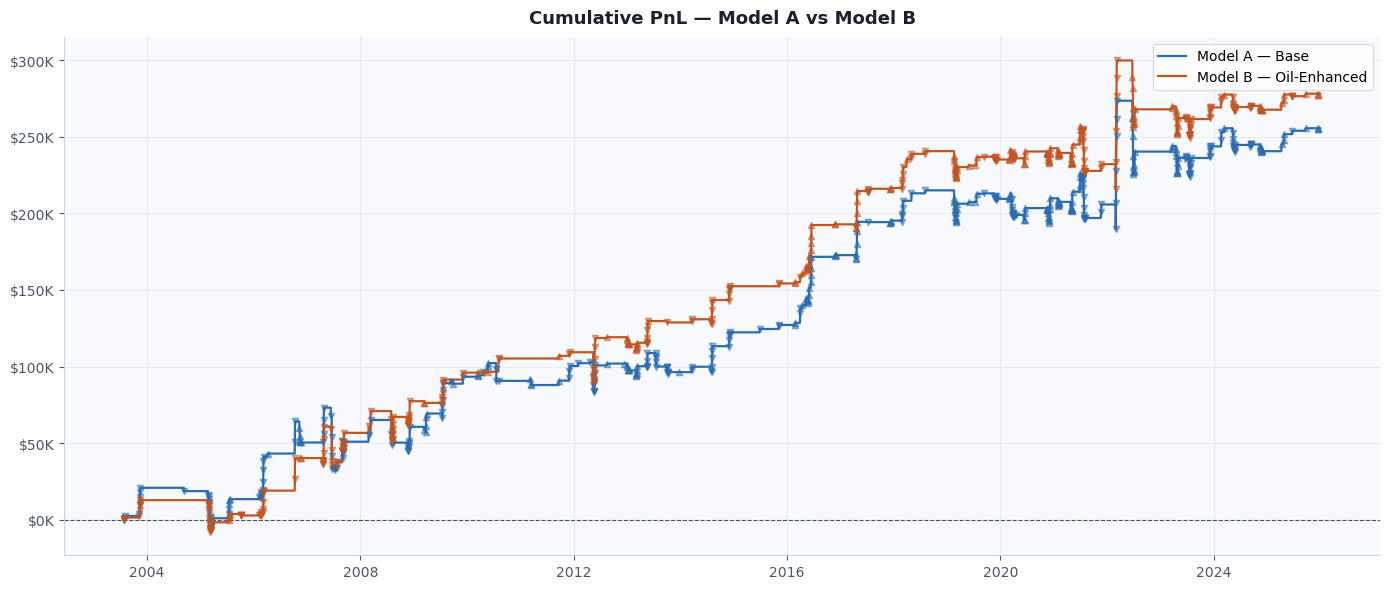

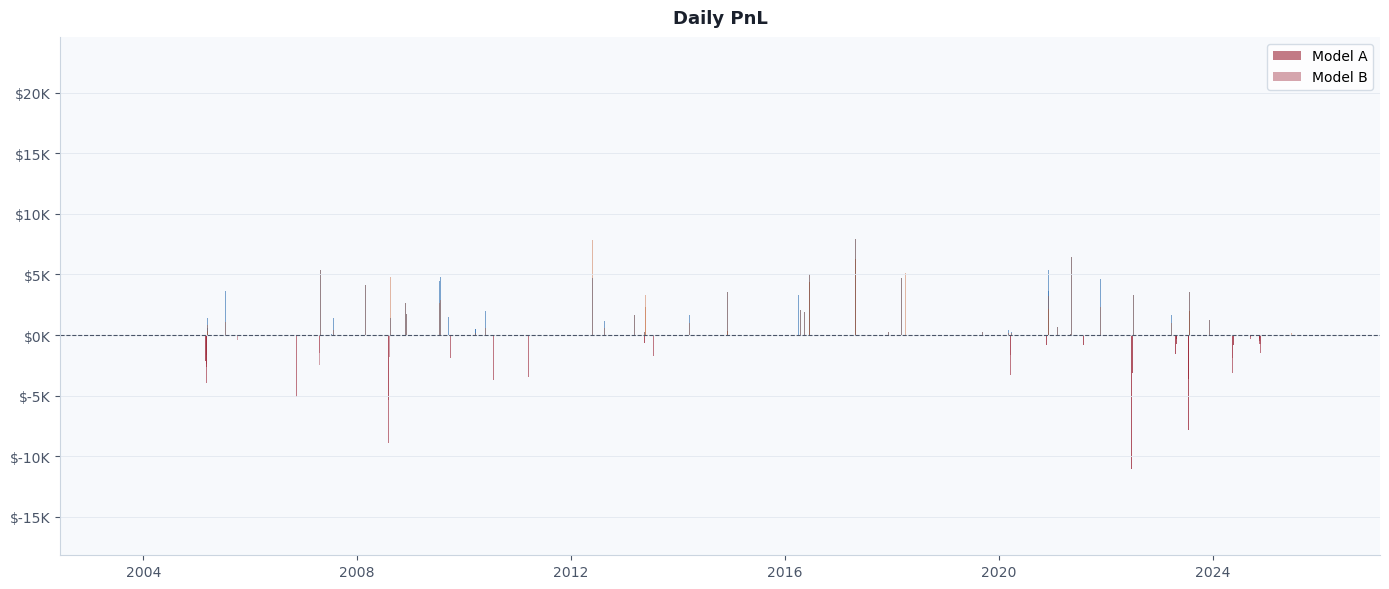

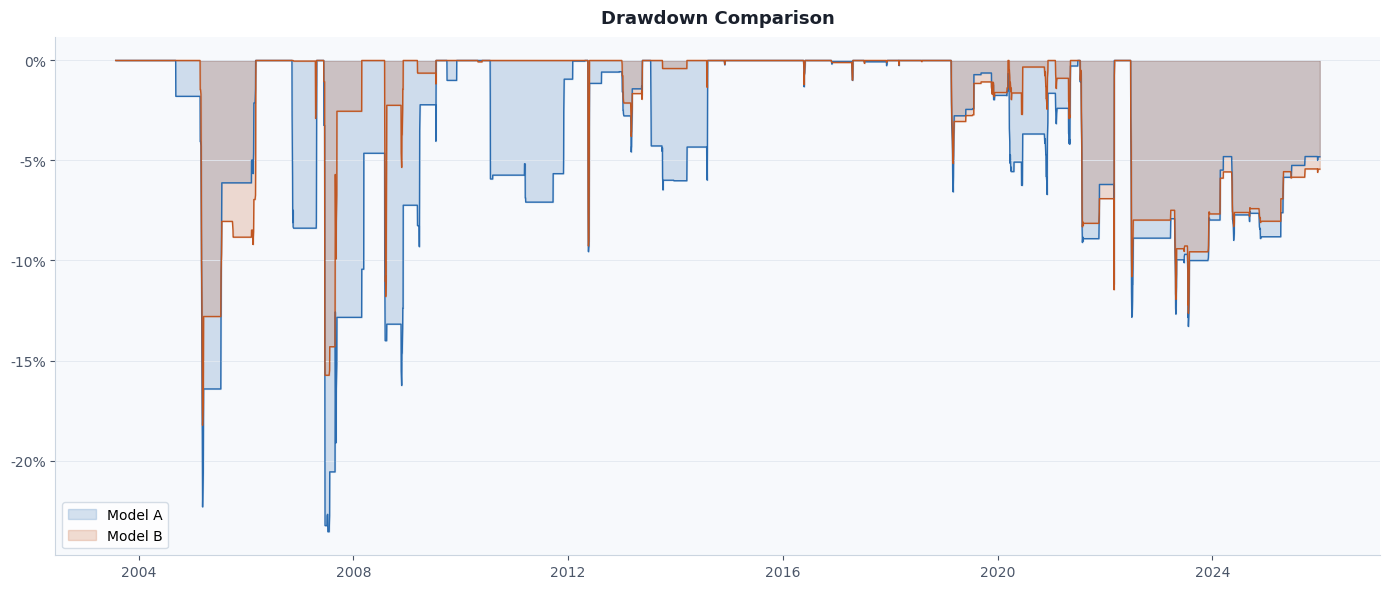

In [132]:
# ── 1. CUMULATIVE PnL PLOT ────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 6), facecolor=LIGHT['bg'])
ax1.set_facecolor(LIGHT['panel'])

for daily_pnl, trades_df, color, label in [
    (daily_pnl_A, trades_A, LIGHT['blue'],   'Model A — Base'),
    (daily_pnl_B, trades_B, LIGHT['orange'], 'Model B — Oil-Enhanced'),
]:
    cumpnl = daily_pnl.cumsum()
    ax1.plot(cumpnl.index, cumpnl, color=color, lw=1.6, label=label)
    long_t  = trades_df[trades_df['direction'] ==  1]
    short_t = trades_df[trades_df['direction'] == -1]
    ax1.scatter(long_t.index,  cumpnl.reindex(long_t.index,  method='ffill'),
                color=color, marker='^', s=20, zorder=4, alpha=0.5)
    ax1.scatter(short_t.index, cumpnl.reindex(short_t.index, method='ffill'),
                color=color, marker='v', s=20, zorder=4, alpha=0.5)

ax1.axhline(0, color=LIGHT['subtext'], lw=0.8, linestyle='--')
ax1.yaxis.set_major_formatter(dollar_fmt)
ax1.set_title('Cumulative PnL — Model A vs Model B', fontweight='bold',
              color=LIGHT['text'], fontsize=13, pad=10)
ax1.legend(framealpha=0.8, edgecolor=LIGHT['border'], fontsize=10)
ax1.grid(color=LIGHT['grid'], lw=0.6)
ax1.tick_params(colors=LIGHT['subtext'])
for spine in ax1.spines.values():
    spine.set_edgecolor(LIGHT['border'])

plt.tight_layout()
plt.savefig('cumulative_pnl.png', dpi=150, bbox_inches='tight', facecolor=LIGHT['bg'])
plt.show()


# ── 2. DAILY PnL BARS PLOT ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6), facecolor=LIGHT['bg'])
ax2.set_facecolor(LIGHT['panel'])

ax2.bar(daily_pnl_A.index, daily_pnl_A,
        color=[LIGHT['blue'] if v >= 0 else LIGHT['red'] for v in daily_pnl_A],
        width=1.5, alpha=0.6, label='Model A')
ax2.bar(daily_pnl_B.index, daily_pnl_B,
        color=[LIGHT['orange'] if v >= 0 else LIGHT['red'] for v in daily_pnl_B],
        width=1.5, alpha=0.4, label='Model B')

ax2.axhline(0, color=LIGHT['subtext'], lw=0.8, linestyle='--')
ax2.yaxis.set_major_formatter(dollar_fmt)
ax2.set_title('Daily PnL', fontweight='bold', color=LIGHT['text'], fontsize=13, pad=10)
ax2.legend(framealpha=0.8, edgecolor=LIGHT['border'], fontsize=10)
ax2.grid(color=LIGHT['grid'], lw=0.6, axis='y')
ax2.tick_params(colors=LIGHT['subtext'])
for spine in ax2.spines.values():
    spine.set_edgecolor(LIGHT['border'])

plt.tight_layout()
plt.savefig('daily_pnl.png', dpi=150, bbox_inches='tight', facecolor=LIGHT['bg'])
plt.show()


# ── 3. DRAWDOWN COMPARISON PLOT ────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 6), facecolor=LIGHT['bg'])
ax3.set_facecolor(LIGHT['panel'])

ax3.fill_between(dd_pct_A.index, dd_pct_A, 0, color=LIGHT['blue'],   alpha=0.2, label='Model A')
ax3.fill_between(dd_pct_B.index, dd_pct_B, 0, color=LIGHT['orange'], alpha=0.2, label='Model B')
ax3.plot(dd_pct_A.index, dd_pct_A, color=LIGHT['blue'],   lw=1.0)
ax3.plot(dd_pct_B.index, dd_pct_B, color=LIGHT['orange'], lw=1.0)

ax3.yaxis.set_major_formatter(pct_fmt)
ax3.set_title('Drawdown Comparison', fontweight='bold', color=LIGHT['text'], fontsize=13, pad=10)
ax3.legend(framealpha=0.8, edgecolor=LIGHT['border'], fontsize=10)
ax3.grid(color=LIGHT['grid'], lw=0.6, axis='y')
ax3.tick_params(colors=LIGHT['subtext'])
for spine in ax3.spines.values():
    spine.set_edgecolor(LIGHT['border'])

plt.tight_layout()
plt.savefig('drawdown_comparison.png', dpi=150, bbox_inches='tight', facecolor=LIGHT['bg'])
plt.show()

## Performance Metrics Comparison

Side-by-side metrics table across all key dimensions: return, risk, and trade quality.

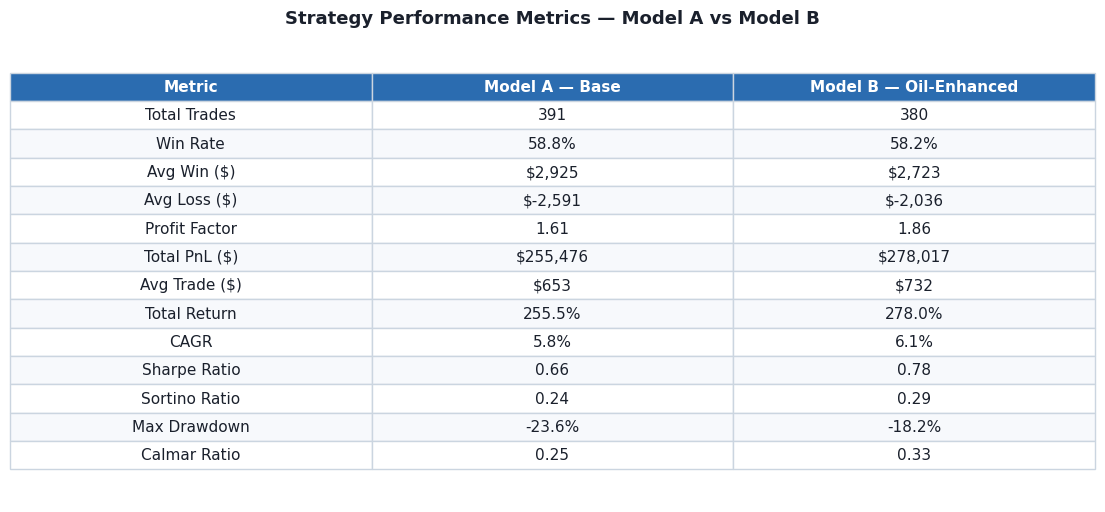

In [131]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor=LIGHT['bg'])
ax.axis('off')

rows       = list(metrics_A.keys())
vals_A     = list(metrics_A.values())
vals_B     = list(metrics_B.values())
table_data = [[r, a, b] for r, a, b in zip(rows, vals_A, vals_B)]

table = ax.table(
    cellText  = table_data,
    colLabels = ['Metric', 'Model A — Base', 'Model B — Oil-Enhanced'],
    cellLoc   = 'center',
    loc       = 'center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 1.7)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor(LIGHT['border'])
    if r == 0:
        cell.set_facecolor(LIGHT['blue'])
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    elif r % 2 == 0:
        cell.set_facecolor(LIGHT['panel'])
        cell.get_text().set_color(LIGHT['text'])
    else:
        cell.set_facecolor(LIGHT['bg'])
        cell.get_text().set_color(LIGHT['text'])

ax.set_title('Strategy Performance Metrics — Model A vs Model B',
             fontweight='bold', color=LIGHT['text'], fontsize=13, pad=12)

plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight', facecolor=LIGHT['bg'])
plt.show()